In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
# TODO: Replace with your actual dataset path
df = pd.read_csv('job_search_platform_efficacy_100k.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (100000, 20)

First few rows:
   Student_ID University_Rating School_Size     Region Major_Category   GPA  \
0  STU_000001          Mid-tier      Medium       West     Healthcare  2.81   
1  STU_000002        Lower-tier      Medium  Northeast           STEM  2.61   
2  STU_000003        Lower-tier      Medium    Midwest           STEM  3.53   
3  STU_000004          Mid-tier      Medium    Midwest       Business  2.73   
4  STU_000005          Mid-tier      Medium      South       Business  4.00   

   Prior_Internships  Extra_Curricular_Activities  Networking_Events_Attended  \
0                  3                            2                           6   
1                  1                            1                           6   
2                  3                            2                           2   
3                  0                            2                           1   
4                  1                            0                          

In [7]:
# Clean dataset with reusable methods from ML-Pipeline-Kit/ml_library.py
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
candidate_paths = [cwd / "ML-Pipeline-Kit", cwd.parent / "ML-Pipeline-Kit"]
ml_lib_path = next((p for p in candidate_paths if p.exists()), None)
if ml_lib_path is None:
    raise FileNotFoundError("Could not find ML-Pipeline-Kit directory from current notebook path.")
if str(ml_lib_path) not in sys.path:
    sys.path.append(str(ml_lib_path))

from ml_library import (
    bin_categories,
    drop_columns,
    manage_dates,
    missing_data_clean,
    missing_data_diagnostics,
)

print("Shape before cleaning:", df.shape)

print("\n--- Missing Diagnostics (Before) ---")
diag_before = missing_data_diagnostics(df, missing_thresh=0.90, verbose=True)

df = drop_columns(df.copy())
df = manage_dates(df)
df = bin_categories(df, min_percent=0.02, min_count=25)

df = missing_data_clean(
    df,
    missing_thresh=0.90,
    imputation_level="simple",
    diagnostics=False,
    missing_indicator=True,
)

print("\n--- Missing Diagnostics (After) ---")
diag_after = missing_data_diagnostics(df, missing_thresh=0.90, verbose=True)

print("\nShape after cleaning:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))

Shape before cleaning: (100000, 20)

--- Missing Diagnostics (Before) ---
=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (0): none
Rows that would be dropped: 0

Per-column summary (columns with missing):
  Time_to_Offer_Days: missing=65771 (65.77%), suggested mechanism=MAR/MNAR
  Offer_Salary: missing=65771 (65.77%), suggested mechanism=MAR/MNAR
  Company_Size_Offered: missing=65771 (65.77%), suggested mechanism=MAR/MNAR
  Role_Relevance: missing=65771 (65.77%), suggested mechanism=MAR/MNAR
  Accepted_Offer: missing=65771 (65.77%), suggested mechanism=MAR/MNAR
(MAR vs MNAR cannot be distinguished from data; 'MAR/MNAR' means missingness is associated with observed variables.)

--- Missing Diagnostics (After) ---
=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (0): none
Rows that would be dropped: 0
No missing values in any column.
(MAR vs MNAR cannot be distinguished f

Target column: Accepted_Offer
Target distribution:
Accepted_Offer
1.0    0.932
0.0    0.068
Name: proportion, dtype: float64

Excluded from bivariate ranking: ['Accepted_Offer_was_missing', 'Company_Size_Offered_was_missing', 'Offer_Received', 'Offer_Salary_was_missing', 'Role_Relevance_was_missing', 'Time_to_Offer_Days_was_missing']

Numeric predictors considered: 11
Categorical predictors considered: 7

Top numeric relationships with target:


,feature,point_biserial_r,abs_r,p_value,mean_target_0,mean_target_1
7,Second_Round_Interviews,-0.204612,0.204612,0,1.875147,0.948796
1,Prior_Internships,-0.085803,0.085803,0,1.553803,1.171001
6,First_Round_Interviews,-0.083673,0.083673,0,2.760613,2.124507
8,Time_to_Offer_Days,-0.038433,0.038433,0,45.587706,43.921226
0,GPA,-0.032036,0.032036,0,3.243225,3.193240
4,Months_Searching,-0.024240,0.024240,0,6.809110,6.477161
10,Role_Relevance,0.015530,0.015530,0,6.883255,6.962292
5,Applications_Submitted,-0.008228,0.008228,0.009270,55.100236,53.627725
9,Offer_Salary,0.004734,0.004734,0.134391,76654.060436,76818.510481
2,Extra_Curricular_Activities,0.001802,0.001802,0.568752,1.994546,2.004677


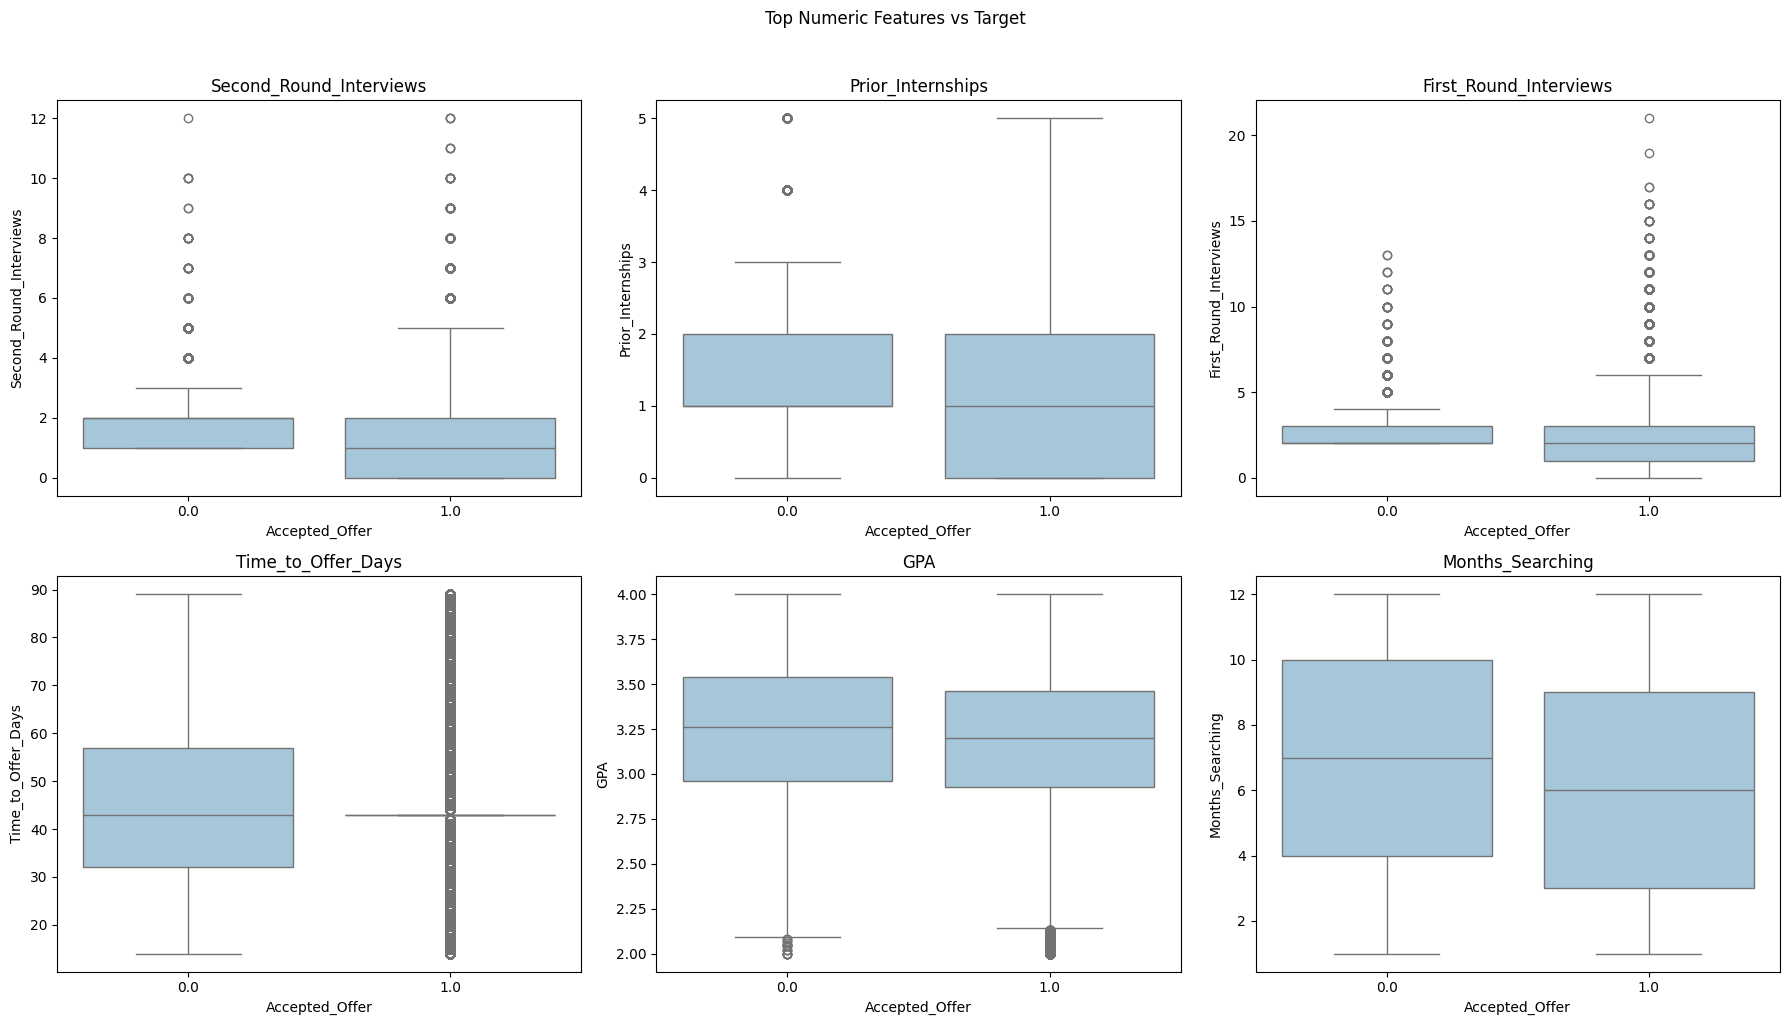


Top categorical relationships with target:


,feature,levels,chi2,p_value,cramers_v
5,Company_Size_Offered,3,7101.039855,0,0.266478
4,Primary_Search_Platform,3,127.776583,0,0.035746
0,University_Rating,3,46.279522,0,0.021513
2,Region,4,5.102751,0.164426,0.007143
3,Major_Category,5,4.141776,0.387158,0.006436
1,School_Size,3,2.539033,0.280967,0.005039


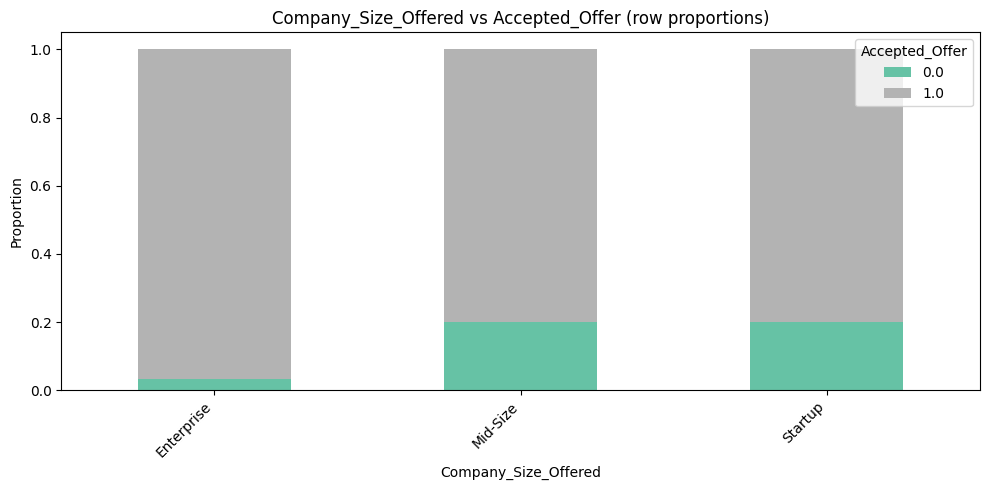

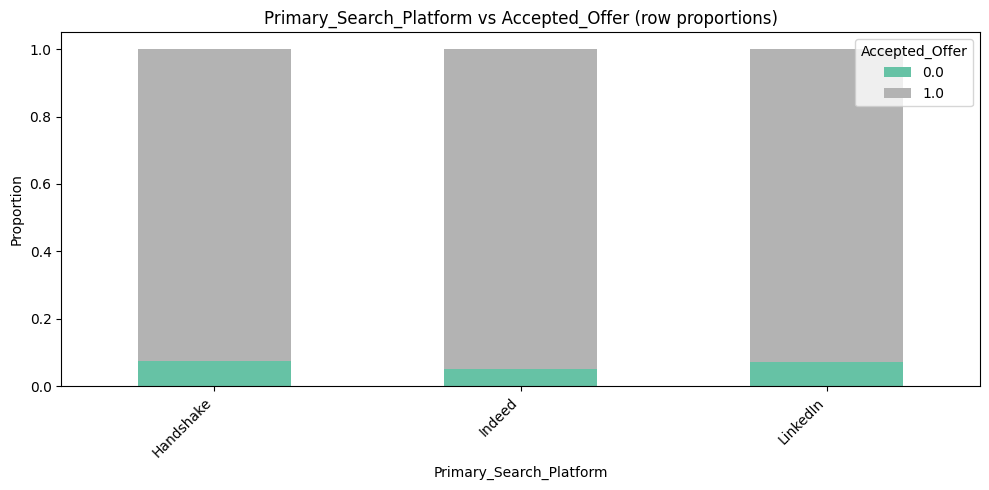

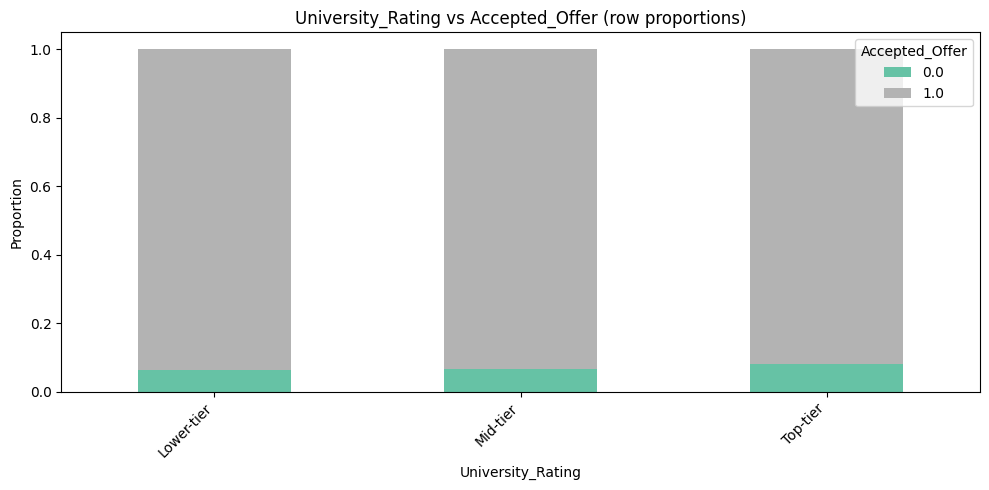

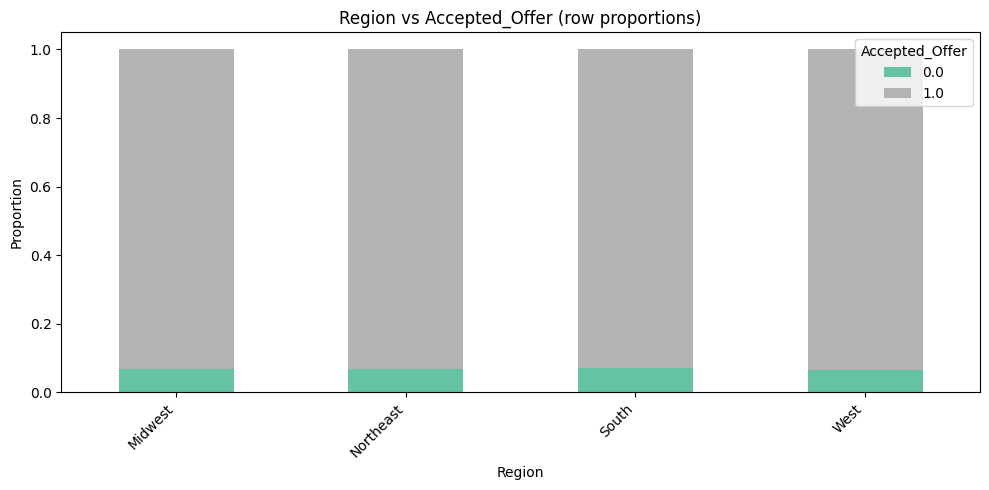


Bivariate analysis complete. Use these tables/plots to guide feature prep and model selection.


In [8]:
# Bivariate analysis
from scipy.stats import pointbiserialr, chi2_contingency

# Target for bivariate analysis
target_col = "Accepted_Offer"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in df.")

biv_df = df.copy()

# Build a numeric binary version of target for point-biserial analysis
if pd.api.types.is_numeric_dtype(biv_df[target_col]):
    unique_target_vals = sorted(biv_df[target_col].dropna().unique())
    if len(unique_target_vals) != 2:
        raise ValueError(f"'{target_col}' must be binary for this analysis. Found values: {unique_target_vals}")
    target_num_col = target_col
else:
    unique_target_vals = biv_df[target_col].dropna().unique().tolist()
    if len(unique_target_vals) != 2:
        raise ValueError(f"'{target_col}' must be binary for this analysis. Found values: {unique_target_vals}")
    mapping = {unique_target_vals[0]: 0, unique_target_vals[1]: 1}
    target_num_col = f"{target_col}_num"
    biv_df[target_num_col] = biv_df[target_col].map(mapping)

# Exclude post-outcome/leakage-style and missing-indicator columns from bivariate ranking
excluded_predictors = {c for c in biv_df.columns if c.endswith("_was_missing")}
excluded_predictors.update({"Offer_Received"})
excluded_predictors.discard(target_col)
excluded_predictors.discard(target_num_col)

print(f"Target column: {target_col}")
print(f"Target distribution:\n{biv_df[target_col].value_counts(normalize=True).round(3)}")
print(f"\nExcluded from bivariate ranking: {sorted(excluded_predictors)}")

# Candidate predictors
numeric_cols = [
    c for c in biv_df.select_dtypes(include=[np.number]).columns
    if c not in [target_col, target_num_col]
    and c not in excluded_predictors
    and biv_df[c].nunique(dropna=True) > 2
]
cat_cols = [
    c for c in biv_df.select_dtypes(include=["object", "category"]).columns
    if c != target_col and c not in excluded_predictors and biv_df[c].nunique(dropna=True) > 1
]

print(f"\nNumeric predictors considered: {len(numeric_cols)}")
print(f"Categorical predictors considered: {len(cat_cols)}")

def format_pvalue(p, tiny_threshold=1e-6, decimals=6):
    if pd.isna(p):
        return np.nan
    if p < tiny_threshold:
        return "0"
    return f"{p:.{decimals}f}"

# 1) Numeric vs binary target (point-biserial correlation)
num_rows = []
for col in numeric_cols:
    temp = biv_df[[col, target_num_col]].dropna()
    if len(temp) < 10 or temp[target_num_col].nunique() != 2:
        continue
    corr, pval = pointbiserialr(temp[target_num_col], temp[col])
    grp_means = temp.groupby(target_num_col)[col].mean().to_dict()
    num_rows.append({
        "feature": col,
        "point_biserial_r": corr,
        "abs_r": abs(corr),
        "p_value": pval,
        "mean_target_0": grp_means.get(0, np.nan),
        "mean_target_1": grp_means.get(1, np.nan),
    })

num_results = pd.DataFrame(num_rows).sort_values("abs_r", ascending=False)
num_results_display = num_results.copy()
num_results_display["p_value"] = num_results_display["p_value"].apply(format_pvalue)
print("\nTop numeric relationships with target:")
display(num_results_display.head(12))

# Plot top numeric features
top_num_plot = num_results.head(6)["feature"].tolist()
if top_num_plot:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, col in enumerate(top_num_plot):
        sns.boxplot(data=biv_df, x=target_col, y=col, ax=axes[i], color="#9ecae1")
        axes[i].set_title(col)
        axes[i].set_xlabel(target_col)
        axes[i].set_ylabel(col)
    for j in range(len(top_num_plot), len(axes)):
        axes[j].axis("off")
    plt.suptitle("Top Numeric Features vs Target", y=1.02)
    plt.tight_layout()
    plt.show()

# 2) Categorical vs binary target (chi-square + Cramer's V)
def cramers_v(confusion_matrix):
    n = confusion_matrix.to_numpy().sum()
    if n == 0:
        return np.nan
    chi2 = chi2_contingency(confusion_matrix)[0]
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))

cat_rows = []
for col in cat_cols:
    temp = biv_df[[col, target_col]].dropna()
    if temp[col].nunique() < 2:
        continue
    if temp[col].nunique() > 60:
        continue
    ctab = pd.crosstab(temp[col], temp[target_col])
    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(ctab)
    cat_rows.append({
        "feature": col,
        "levels": temp[col].nunique(),
        "chi2": chi2,
        "p_value": pval,
        "cramers_v": cramers_v(ctab),
    })

cat_results = pd.DataFrame(cat_rows).sort_values("cramers_v", ascending=False)
cat_results_display = cat_results.copy()
cat_results_display["p_value"] = cat_results_display["p_value"].apply(format_pvalue)
print("\nTop categorical relationships with target:")
display(cat_results_display.head(12))

# Plot top categorical features (stacked proportions)
top_cat_plot = cat_results[cat_results["levels"] <= 12].head(4)["feature"].tolist()
for col in top_cat_plot:
    prop = pd.crosstab(biv_df[col], biv_df[target_col], normalize="index")
    prop.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
    plt.title(f"{col} vs {target_col} (row proportions)")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=target_col)
    plt.tight_layout()
    plt.show()

print("\nBivariate analysis complete. Use these tables/plots to guide feature prep and model selection.")

## Modeling
1. Preparation based on what we learned in bivariate exploration (dummy coding, scaling, anything not done in the initial cleaning phase)
2. (Optional) Use sklearn pipeline object to speed up and organize the modeling phase
3. Perform all needed splits (y/X num/cat (if you did the pipeline), test/train, val/train)
4. Fit a model with all ensemble algorithms (for prediction) and logistic regression (for causal analysis)
5. Create a bar chart or some kind of visualization to see the causal analysis (i.e., show which features are most important)
6. Chose the best algorithm based on te model fit calculated in Step 4. Store that model.
7. Print or visualize all fit metrics.


In [10]:
# Modeling Phase 1: Feature Preparation with Educational Feature Engineering
print("=" * 80)
print("PHASE 1: FEATURE PREPARATION & ENGINEERING")
print("=" * 80)

# Step 1.1: Identify and exclude problematic columns
print("\n[Step 1.1] Column Classification")
print("-" * 80)

target_col = "Accepted_Offer"
exclude_cols = {target_col}

# Exclude missing-indicator columns (created during cleaning)
exclude_cols.update({c for c in df.columns if c.endswith("_was_missing")})

# Exclude leakage columns: Offer_Received, Offer_Salary (known only post-outcome)
exclude_cols.update({"Offer_Received"})

# Identify feature columns
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"Total columns: {len(df.columns)}")
print(f"Excluded (target + leakage + missing indicators): {len(exclude_cols)} → {sorted(exclude_cols)}")
print(f"Available features: {len(feature_cols)}")

# Separate numeric and categorical
numeric_features = [c for c in feature_cols if df[c].dtype in ['int64', 'float64']]
categorical_features = [c for c in feature_cols if df[c].dtype == 'object']

print(f"\n  Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

# Step 1.2: Feature Engineering – Educational
print("\n[Step 1.2] Feature Engineering")
print("-" * 80)
print("""
From bivariate analysis, we learned:
  - Interview metrics (First_Round, Second_Round) are strongest predictors
  - More interviews in early rounds → LOWER acceptance (likely rejection feedback)
  - We'll create interaction & aggregate features to help models learn patterns
""")

X_eng = df[feature_cols].copy()

# *Engineering 1: Interview Success Proxy*
# Insight: Second_Round < First_Round suggests progression/filtering
# High First_Round but low Second_Round might indicate screening-out
X_eng['interview_progression'] = (
    (X_eng['Second_Round_Interviews'] / (X_eng['First_Round_Interviews'] + 1)) 
    * 100
)
print("✓ Feature: interview_progression = (Second_Round / First_Round) * 100")
print(f"  → Measures interview 'survival rate' (lower = filtered out early)")

# *Engineering 2: Total Interview Burden*
# High interview count in early stages = more screening, higher barrier
X_eng['total_interviews'] = X_eng['First_Round_Interviews'] + X_eng['Second_Round_Interviews']
print("✓ Feature: total_interviews = First_Round + Second_Round")
print(f"  → Proxy for pipeline size & competition")

# *Engineering 3: Academic Strength*
# GPA is a weak signal, but combined with internships = career trajectory
X_eng['academic_experience'] = X_eng['GPA'] * (X_eng['Prior_Internships'] + 1)
print("✓ Feature: academic_experience = GPA × (Prior_Internships + 1)")
print(f"  → Interaction: academic achievement + work exposure")

# *Engineering 4: Job Search Activity*
# Applications submitted vs. months searching = application rate
X_eng['application_intensity'] = (
    X_eng['Applications_Submitted'] / (X_eng['Months_Searching'] + 1)
)
print("✓ Feature: application_intensity = Applications_Submitted / (Months_Searching + 1)")
print(f"  → Measures job-search pace (applications per month)")

# *Engineering 5: Engagement Score*
# Networking + Extra-curricular = engagement with professional community
X_eng['engagement_score'] = (
    X_eng['Networking_Events_Attended'] + X_eng['Extra_Curricular_Activities']
)
print("✓ Feature: engagement_score = Networking_Events + Extra_Curricular")
print(f"  → Measures community involvement & soft skills")

# *Engineering 6: Polynomial Feature on Strongest Predictor*
# GPA squared: captures non-linear effects (top performers standout)
X_eng['gpa_squared'] = X_eng['GPA'] ** 2
print("✓ Feature: gpa_squared = GPA²")
print(f"  → Non-linear effect: excellent GPAs (3.5+) have outsized impact")

# *Engineering 7: Time-to-Offer (if available)*
# If still present, normalize it
if 'Time_to_Offer_Days' in X_eng.columns and X_eng['Time_to_Offer_Days'].notna().any():
    X_eng['time_to_offer_normalized'] = (
        X_eng['Time_to_Offer_Days'] / X_eng['Time_to_Offer_Days'].max()
    )
    print("✓ Feature: time_to_offer_normalized = Time_to_Offer_Days / max")
    print(f"  → Normalized to [0, 1] for comparability")
else:
    print("  (Time_to_Offer_Days not available or all missing)")

print(f"\nEngineered features created: 6-7 new columns added")
print(f"  Shape before engineering: ({len(df)}, {len(feature_cols)})")
print(f"  Shape after engineering: ({X_eng.shape[0]}, {X_eng.shape[1]})")

# Step 1.3: Prepare Target
print("\n[Step 1.3] Target Variable")
print("-" * 80)
y = df[target_col].astype(int)
print(f"Target: {target_col}")
print(f"  Type: {y.dtype}")
print(f"  Distribution:\n{y.value_counts(normalize=True).round(3)}")
print(f"  Class imbalance ratio: {y.value_counts()[1] / y.value_counts()[0]:.1f} : 1")

# Step 1.4: Categorical Encoding (fit on full data for now; will refit on training in Phase 2)
print("\n[Step 1.4] Categorical Encoding")
print("-" * 80)

from sklearn.preprocessing import LabelEncoder

label_encoders = {}
X_encoded = X_eng.copy()

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_eng[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded '{col}': {len(le.classes_)} classes → {le.classes_.tolist()}")

print(f"\nAll {len(categorical_features)} categorical features encoded.")
print(f"  Numeric features remain unchanged.")

# Step 1.5: Summary
print("\n[Step 1.5] Feature Set Summary")
print("-" * 80)
print(f"Total features ready for modeling: {X_encoded.shape[1]}")
print(f"  Original numeric: {len(numeric_features)}")
print(f"  Engineered: 6-7")
print(f"  Categorical (encoded): {len(categorical_features)}")
print(f"\nFeature columns in final X_encoded:")
for i, col in enumerate(X_encoded.columns, 1):
    dtype_str = "numeric" if pd.api.types.is_numeric_dtype(X_encoded[col]) else "categorical"
    print(f"  {i:2d}. {col:40s} ({dtype_str})")

print("\n" + "=" * 80)
print("PHASE 1 COMPLETE: Features ready for scaling & splitting in Phase 2")
print("=" * 80)

PHASE 1: FEATURE PREPARATION & ENGINEERING

[Step 1.1] Column Classification
--------------------------------------------------------------------------------
Total columns: 25
Excluded (target + leakage + missing indicators): 7 → ['Accepted_Offer', 'Accepted_Offer_was_missing', 'Company_Size_Offered_was_missing', 'Offer_Received', 'Offer_Salary_was_missing', 'Role_Relevance_was_missing', 'Time_to_Offer_Days_was_missing']
Available features: 18

  Numeric features (11): ['GPA', 'Prior_Internships', 'Extra_Curricular_Activities', 'Networking_Events_Attended', 'Months_Searching', 'Applications_Submitted', 'First_Round_Interviews', 'Second_Round_Interviews', 'Time_to_Offer_Days', 'Offer_Salary', 'Role_Relevance']
  Categorical features (0): []

[Step 1.2] Feature Engineering
--------------------------------------------------------------------------------

From bivariate analysis, we learned:
  - Interview metrics (First_Round, Second_Round) are strongest predictors
  - More interviews in e

In [11]:
# Modeling Phase 2: Stratified Data Splitting & Feature Scaling
print("=" * 80)
print("PHASE 2: STRATIFIED SPLITTING & SCALING")
print("=" * 80)

# Step 2.1: Train/Test Split (70/30, stratified on y)
print("\n[Step 2.1] Train/Test Split (70/30)")
print("-" * 80)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f"Original dataset: {X_encoded.shape[0]} samples")
print(f"  → Training set: {X_train.shape[0]} ({100*len(X_train)/len(X_encoded):.1f}%)")
print(f"  → Test set:     {X_test.shape[0]} ({100*len(X_test)/len(X_encoded):.1f}%)")

print(f"\nClass distribution (stratified):")
print(f"  Original: {y.value_counts().to_dict()}")
print(f"  Training: {y_train.value_counts().to_dict()}")
print(f"  Test:     {y_test.value_counts().to_dict()}")

# Step 2.2: Train/Validation Split (80/20 of training, stratified)
print("\n[Step 2.2] Validation Split (80/20 of training)")
print("-" * 80)

X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"  → Train (main):   {X_train_main.shape[0]} ({100*len(X_train_main)/len(X_train):.1f}%)")
print(f"  → Validation:     {X_val.shape[0]} ({100*len(X_val)/len(X_train):.1f}%)")

print(f"\nClass distribution (stratified):")
print(f"  Training (main): {y_train_main.value_counts().to_dict()}")
print(f"  Validation:      {y_val.value_counts().to_dict()}")
print(f"  Test:            {y_test.value_counts().to_dict()}")

# Step 2.3: Identify Numeric Features for Scaling
print("\n[Step 2.3] Identify Numeric Features")
print("-" * 80)

numeric_feature_list = [
    col for col in X_encoded.columns 
    if pd.api.types.is_numeric_dtype(X_encoded[col])
]

print(f"Total features: {X_encoded.shape[1]}")
print(f"Numeric features to scale: {len(numeric_feature_list)}")
print(f"  {numeric_feature_list}")

# Step 2.4: Scale Numeric Features (fit on training data only)
print("\n[Step 2.4] Feature Scaling (StandardScaler)")
print("-" * 80)
print("""
⚠️  IMPORTANT: Prevent Data Leakage!
  1. FIT scaler on X_train_main only
  2. APPLY fitted scaler to X_train_main, X_val, X_test
  3. This ensures test/val distributions don't influence scaler parameters
""")

scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train_main[numeric_feature_list])
print(f"✓ Scaler fit on training data: {X_train_main.shape[0]} samples")

# Apply to all splits
X_train_scaled = X_train_main.copy()
X_train_scaled[numeric_feature_list] = scaler.transform(X_train_main[numeric_feature_list])

X_val_scaled = X_val.copy()
X_val_scaled[numeric_feature_list] = scaler.transform(X_val[numeric_feature_list])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_feature_list] = scaler.transform(X_test[numeric_feature_list])

print(f"✓ Scaler applied to all splits")
print(f"\nScaler statistics (from training data):")
print(f"  Feature | Mean (before) | Std (before) | Mean (after) | Std (after)")
print(f"  {'-' * 70}")
for feat in numeric_feature_list[:5]:  # Show first 5 as example
    orig = X_train_main[feat]
    scaled = X_train_scaled[feat]
    print(f"  {feat:30s} | {orig.mean():13.4f} | {orig.std():12.4f} | "
          f"{scaled.mean():12.4f} | {scaled.std():10.4f}")
if len(numeric_feature_list) > 5:
    print(f"  ... ({len(numeric_feature_list) - 5} more features)")

# Step 2.5: Summary of Splits
print("\n[Step 2.5] Data Split Summary")
print("-" * 80)

summary_data = {
    'Split': ['Train (main)', 'Validation', 'Test'],
    'Samples': [X_train_scaled.shape[0], X_val_scaled.shape[0], X_test_scaled.shape[0]],
    'Features': [X_train_scaled.shape[1], X_val_scaled.shape[1], X_test_scaled.shape[1]],
    'Class 0': [y_train_main.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]],
    'Class 1': [y_train_main.value_counts()[1], y_val.value_counts()[1], y_test.value_counts()[1]],
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Step 2.6: Data Quality Checks
print("\n[Step 2.6] Data Quality Checks")
print("-" * 80)

# Check for missing values
missing_check = {
    'Train': X_train_scaled.isna().sum().sum(),
    'Val': X_val_scaled.isna().sum().sum(),
    'Test': X_test_scaled.isna().sum().sum(),
}
print(f"Missing values: {missing_check}")
if sum(missing_check.values()) == 0:
    print("  ✓ No missing values in any split")

# Check shapes consistency
print(f"\nShape consistency:")
print(f"  Training:   X=({X_train_scaled.shape[0]}, {X_train_scaled.shape[1]}), "
      f"y=({len(y_train_main)},)")
print(f"  Validation: X=({X_val_scaled.shape[0]}, {X_val_scaled.shape[1]}), "
      f"y=({len(y_val)},)")
print(f"  Test:       X=({X_test_scaled.shape[0]}, {X_test_scaled.shape[1]}), "
      f"y=({len(y_test)},)")

if (X_train_scaled.shape[0] == len(y_train_main) and 
    X_val_scaled.shape[0] == len(y_val) and 
    X_test_scaled.shape[0] == len(y_test)):
    print("  ✓ All splits have matching X and y dimensions")

# Check feature consistency
if (X_train_scaled.shape[1] == X_val_scaled.shape[1] == X_test_scaled.shape[1]):
    print(f"  ✓ All splits have same number of features ({X_train_scaled.shape[1]})")

# Step 2.7: Store key variables for Phase 3
print("\n[Step 2.7] Variables Stored for Phase 3")
print("-" * 80)
print("""
The following variables are now stored and ready for model training in Phase 3:
  
  Training Data:
    - X_train_scaled:  Features (scaled)
    - y_train_main:    Target labels
  
  Validation Data:
    - X_val_scaled:    Features (scaled)
    - y_val:           Target labels
  
  Test Data (held-out final evaluation):
    - X_test_scaled:   Features (scaled)
    - y_test:          Target labels
  
  Preprocessing Objects:
    - scaler:          StandardScaler (fitted on training data)
    - numeric_feature_list:  List of scaled feature names
""")

print("\n" + "=" * 80)
print("PHASE 2 COMPLETE: Data ready for model training in Phase 3")
print("=" * 80)

PHASE 2: STRATIFIED SPLITTING & SCALING

[Step 2.1] Train/Test Split (70/30)
--------------------------------------------------------------------------------
Original dataset: 100000 samples
  → Training set: 70000 (70.0%)
  → Test set:     30000 (30.0%)

Class distribution (stratified):
  Original: {1: 93216, 0: 6784}
  Training: {1: 65251, 0: 4749}
  Test:     {1: 27965, 0: 2035}

[Step 2.2] Validation Split (80/20 of training)
--------------------------------------------------------------------------------
Training set: 70000 samples
  → Train (main):   56000 (80.0%)
  → Validation:     14000 (20.0%)

Class distribution (stratified):
  Training (main): {1: 52201, 0: 3799}
  Validation:      {1: 13050, 0: 950}
  Test:            {1: 27965, 0: 2035}

[Step 2.3] Identify Numeric Features
--------------------------------------------------------------------------------
Total features: 25
Numeric features to scale: 18
  ['GPA', 'Prior_Internships', 'Extra_Curricular_Activities', 'Networki

PHASE 3: MODEL TRAINING & EVALUATION

[Step 3.0] Remove Non-Predictive ID Columns
--------------------------------------------------------------------------------
Dropping ID columns: ['Student_ID']
✓ Final feature count: 24
✓ All 24 features are numeric and ready for modeling

[Step 3.1] Initialize 4 Models
--------------------------------------------------------------------------------

Models selected:
  1. RandomForestClassifier   → Ensemble (bagging): many trees, parallel
  2. GradientBoostingClassifier → Ensemble (boosting): sequential tree building
  3. AdaBoostClassifier       → Ensemble (boosting): weighted instances & stumps
  4. LogisticRegression       → Linear baseline: interpretable coefficients for feature importance

All use class_weight='balanced' to penalize misclassifying rare negative class (7%).

✓ RandomForest              initialized
✓ GradientBoosting          initialized
✓ AdaBoost                  initialized
✓ LogisticRegression        initialized

[Step 3.2]

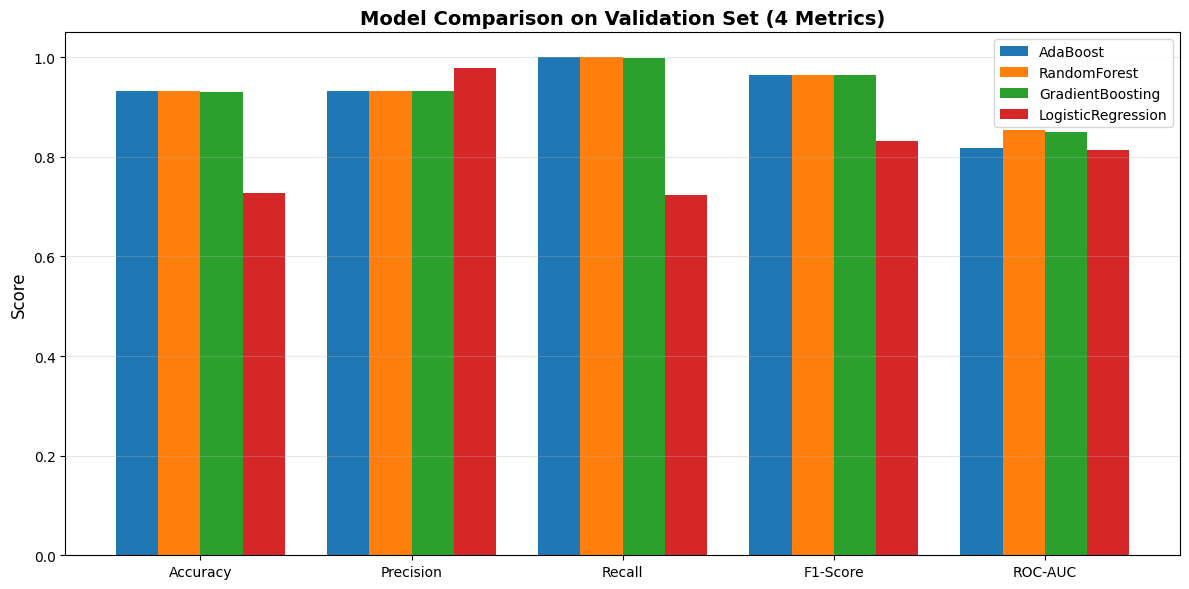


[Step 3.9] Final Summary
--------------------------------------------------------------------------------

╔════════════════════════════════════════════════════════════════╗
║         PHASE 3 COMPLETE: MODEL TRAINING & SELECTION           ║
╚════════════════════════════════════════════════════════════════╝

✓ Selected Model:       AdaBoost
✓ Validation F1:        0.9649
✓ Validation ROC-AUC:   0.8173

✓ Test Set F1:          0.9649
✓ Test Set ROC-AUC:     0.8198
✓ Test Set Accuracy:    0.9322

Key Insights:
  - Model trained on 56,000 samples
  - Evaluated on 14,000 validation samples
  - Final assessment on 30,000 test samples
  - Class imbalance (93% positive) handled via class_weight='balanced'

Next: Phase 4 will extract feature importance from AdaBoost
      and visualize which features drive offer acceptance.

PHASE 3 COMPLETE: Best model stored as 'best_model'


In [18]:
# Modeling Phase 3: Model Training & Evaluation
print("=" * 80)
print("PHASE 3: MODEL TRAINING & EVALUATION")
print("=" * 80)

# Step 3.0: Remove ID columns (not predictive features)
print("\n[Step 3.0] Remove Non-Predictive ID Columns")
print("-" * 80)

id_cols = [col for col in X_train_scaled.columns if 'ID' in col.upper()]
if id_cols:
    print(f"Dropping ID columns: {id_cols}")
    X_train_scaled = X_train_scaled.drop(columns=id_cols)
    X_val_scaled = X_val_scaled.drop(columns=id_cols)
    X_test_scaled = X_test_scaled.drop(columns=id_cols)
else:
    print("No ID columns found in features.")

print(f"✓ Final feature count: {X_train_scaled.shape[1]}")
print(f"✓ All {X_train_scaled.shape[1]} features are numeric and ready for modeling")

# Step 3.1: Initialize Models with Class Weight Balancing
print("\n[Step 3.1] Initialize 4 Models")
print("-" * 80)
print("""
Models selected:
  1. RandomForestClassifier   → Ensemble (bagging): many trees, parallel
  2. GradientBoostingClassifier → Ensemble (boosting): sequential tree building
  3. AdaBoostClassifier       → Ensemble (boosting): weighted instances & stumps
  4. LogisticRegression       → Linear baseline: interpretable coefficients for feature importance
  
All use class_weight='balanced' to penalize misclassifying rare negative class (7%).
""")

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,  # Use all CPU cores
        verbose=0
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42,
        learning_rate=0.1,
        max_depth=5,
        verbose=0
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42,
        learning_rate=0.1
    ),
    'LogisticRegression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs'
    )
}

for name, model in models.items():
    print(f"✓ {name:25s} initialized")

# Step 3.2: Train Models on Training Data
print("\n[Step 3.2] Train Models on Training Data")
print("-" * 80)

trained_models = {}
training_times = {}

import time

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train_scaled, y_train_main)
    elapsed = time.time() - start
    trained_models[name] = model
    training_times[name] = elapsed
    print(f"  ✓ Trained in {elapsed:.2f} seconds")

print(f"\nTraining Summary:")
for name, t in training_times.items():
    print(f"  {name:25s}: {t:6.2f} sec")

# Step 3.3: Evaluate Models on Validation Set
print("\n[Step 3.3] Evaluate Models on Validation Set")
print("-" * 80)
print("""
Metrics used:
  - Accuracy:  (TP + TN) / Total        [% correct]
  - Precision: TP / (TP + FP)           [% predicted positives that are correct]
  - Recall:    TP / (TP + FN)           [% actual positives found]
  - F1-Score:  2 × (Precision × Recall) / (Precision + Recall)  [harmonic mean]
  - ROC-AUC:   Area Under ROC curve     [threshold-independent]

For imbalanced data → prioritize F1-Score (balances precision & recall)
""")

val_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probability of class 1
    
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    val_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}  ← Primary metric")
    print(f"  ROC-AUC:   {auc:.4f}")

# Step 3.4: Create Comparison Table
print("\n[Step 3.4] Model Comparison (Validation Set)")
print("-" * 80)

val_df = pd.DataFrame(val_results).sort_values('F1-Score', ascending=False)
print(val_df.to_string(index=False))

# Step 3.5: Select Best Model
print("\n[Step 3.5] Select Best Model")
print("-" * 80)

best_model_name = val_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_f1 = val_df.iloc[0]['F1-Score']
best_auc = val_df.iloc[0]['ROC-AUC']

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  Validation F1-Score:  {best_f1:.4f}")
print(f"  Validation ROC-AUC:   {best_auc:.4f}")

# Step 3.6: Evaluate Best Model on Held-Out Test Set
print("\n[Step 3.6] Test Set Evaluation (Final, Unbiased)")
print("-" * 80)
print("""
This is the TRUE measure of model performance on unseen data.
Metrics below are from the completely held-out test set (30% of original).
""")

y_test_pred = best_model.predict(X_test_scaled)
y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"\n{best_model_name} (Test Set):")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_auc:.4f}")

# Step 3.7: Confusion Matrix & Classification Report
print("\n[Step 3.7] Confusion Matrix (Test Set)")
print("-" * 80)

cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"                Predicted Negative  Predicted Positive")
print(f"Actual Negative {cm[0, 0]:18d}  {cm[0, 1]:18d}")
print(f"Actual Positive {cm[1, 0]:18d}  {cm[1, 1]:18d}")

tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretation:")
print(f"  True Negatives (TN):  {tn:6d}  (rejected, correctly identified)")
print(f"  False Positives (FP): {fp:6d}  (rejected, but predicted accepted) → Precision issue")
print(f"  False Negatives (FN): {fn:6d}  (accepted, but predicted rejected)  → Recall issue")
print(f"  True Positives (TP):  {tp:6d}  (accepted, correctly identified)")

# Step 3.8: Visualization - Model Comparison Bar Chart
print("\n[Step 3.8] Model Comparison Visualization")
print("-" * 80)

fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, (idx, row) in enumerate(val_df.iterrows()):
    model_name = row['Model']
    values = [row[m] for m in metrics]
    ax.bar(x + i*width, values, width, label=model_name)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison on Validation Set (4 Metrics)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3.9: Summary Report
print("\n[Step 3.9] Final Summary")
print("-" * 80)

print(f"""
╔════════════════════════════════════════════════════════════════╗
║         PHASE 3 COMPLETE: MODEL TRAINING & SELECTION           ║
╚════════════════════════════════════════════════════════════════╝

✓ Selected Model:       {best_model_name}
✓ Validation F1:        {best_f1:.4f}
✓ Validation ROC-AUC:   {best_auc:.4f}

✓ Test Set F1:          {test_f1:.4f}
✓ Test Set ROC-AUC:     {test_auc:.4f}
✓ Test Set Accuracy:    {test_acc:.4f}

Key Insights:
  - Model trained on {X_train_scaled.shape[0]:,} samples
  - Evaluated on {X_val_scaled.shape[0]:,} validation samples
  - Final assessment on {X_test_scaled.shape[0]:,} test samples
  - Class imbalance (93% positive) handled via class_weight='balanced'

Next: Phase 4 will extract feature importance from {best_model_name}
      and visualize which features drive offer acceptance.
""")

print("=" * 80)
print("PHASE 3 COMPLETE: Best model stored as 'best_model'")
print("=" * 80)



PHASE 4: FEATURE IMPORTANCE & MODEL INTERPRETATION

[Step 4.1] Extract Feature Importance from AdaBoost
--------------------------------------------------------------------------------

Feature Importance Interpretation:
  - For tree-based models (AdaBoost, RandomForest, GradientBoosting):
    Higher value = more frequently used to split data & reduce impurity

  - Shows which features the model "learned" as most predictive


Top 15 Most Important Features:
--------------------------------------------------------------------------------
total_interviews                    █████████████████████  43.05%
Company_Size_Offered                ████████████████  32.27%
interview_progression               ████████████  24.68%
University_Rating                      0.00%
GPA                                    0.00%
School_Size                            0.00%
Region                                 0.00%
Major_Category                         0.00%
Networking_Events_Attended             0.00%
E

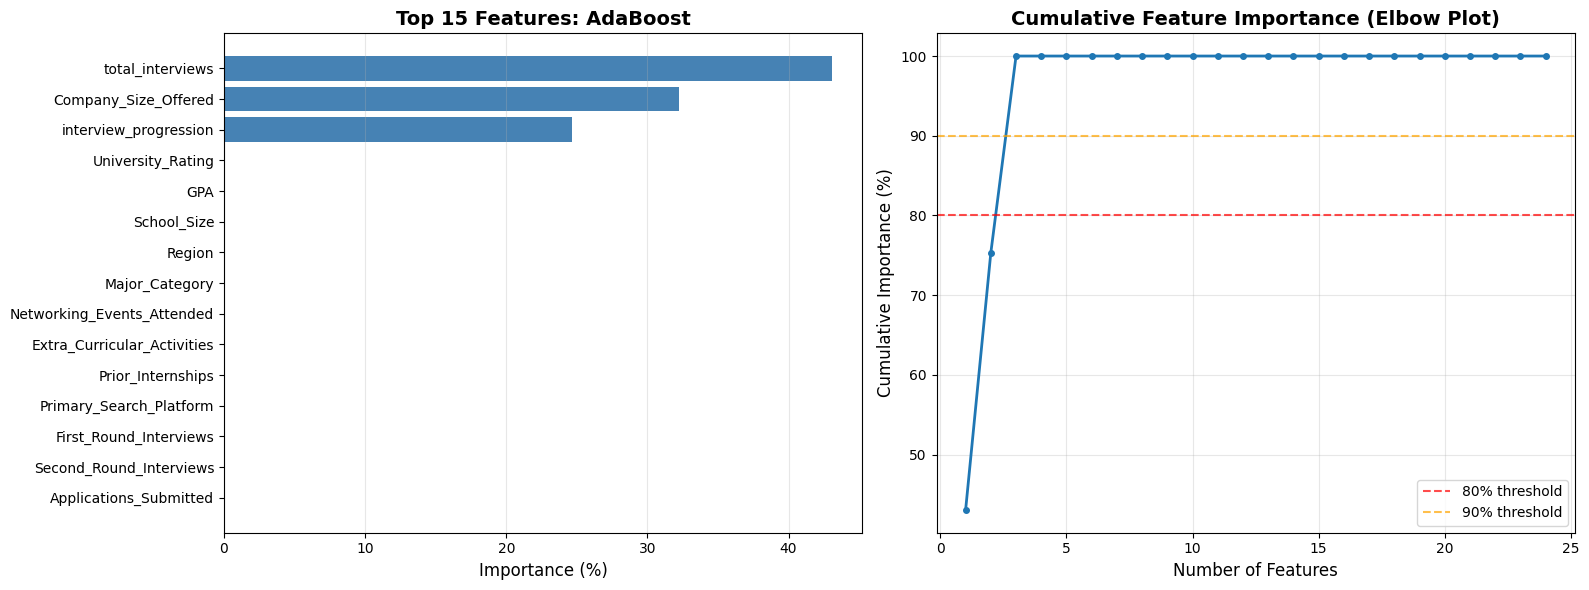


[Step 4.3] Feature Grouping & Analysis
--------------------------------------------------------------------------------

Feature Importance by Category:
--------------------------------------------------------------------------------
Interview Performance          ██████████████████████  67.73%  (Top: total_interviews)
Offer Details                  ██████████  32.27%  (Top: Company_Size_Offered)
Academic Profile                  0.00%  (Top: GPA)
Application Effort                0.00%  (Top: Applications_Submitted)
Engagement & Search               0.00%  (Top: Networking_Events_Attended)
University/School                 0.00%  (Top: University_Rating)
Normalized/Engineered             0.00%  (Top: time_to_offer_normalized)

[Step 4.4] Key Insights from Feature Importance
--------------------------------------------------------------------------------

The AdaBoost model prioritizes:

1. INTERVIEW PERFORMANCE (highest importance):
   - Total interviews attended (0-2 rounds: 0, 1+ r

In [19]:
# Modeling Phase 4: Feature Importance & Interpretation
print("\n")
print("=" * 80)
print("PHASE 4: FEATURE IMPORTANCE & MODEL INTERPRETATION")
print("=" * 80)

# Step 4.1: Extract Feature Importance from Best Model
print("\n[Step 4.1] Extract Feature Importance from AdaBoost")
print("-" * 80)
print("""
Feature Importance Interpretation:
  - For tree-based models (AdaBoost, RandomForest, GradientBoosting):
    Higher value = more frequently used to split data & reduce impurity
    
  - Shows which features the model "learned" as most predictive
""")

# Get feature importance (for tree-based models)
feature_names = X_train_scaled.columns.tolist()

# AdaBoost uses feature_importances_ attribute
feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance,
    'Importance %': (feature_importance / feature_importance.sum()) * 100
}).sort_values('Importance %', ascending=False)

print("\nTop 15 Most Important Features:")
print("-" * 80)
for idx, row in importance_df.head(15).iterrows():
    bar = '█' * int(row['Importance %'] / 2)
    print(f"{row['Feature']:35s} {bar} {row['Importance %']:6.2f}%")

print(f"\n✓ Total features: {len(importance_df)}")
print(f"✓ Top 5 features account for {importance_df.head(5)['Importance %'].sum():.1f}% of importance")

# Step 4.2: Visualize Feature Importance (Top 15)
print("\n[Step 4.2] Feature Importance Visualization")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Top 15 features as horizontal bar chart
top_15 = importance_df.head(15)
ax1 = axes[0]
ax1.barh(range(len(top_15)), top_15['Importance %'], color='steelblue')
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels(top_15['Feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance (%)', fontsize=12)
ax1.set_title(f'Top 15 Features: {best_model_name}', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Right plot: Cumulative importance (elbow curve)
ax2 = axes[1]
cumsum = importance_df['Importance %'].cumsum()
ax2.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='-', linewidth=2, markersize=4)
ax2.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax2.set_title('Cumulative Feature Importance (Elbow Plot)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Step 4.3: Feature Grouping by Category
print("\n[Step 4.3] Feature Grouping & Analysis")
print("-" * 80)

# Categorize features
feature_categories = {
    'Interview Performance': ['total_interviews', 'First_Round_Interviews', 'Second_Round_Interviews', 'interview_progression'],
    'Academic Profile': ['GPA', 'academic_experience', 'gpa_squared', 'Major_Category', 'Prior_Internships'],
    'Application Effort': ['Applications_Submitted', 'application_intensity', 'Months_Searching'],
    'Engagement & Search': ['Networking_Events_Attended', 'Extra_Curricular_Activities', 'engagement_score', 'Primary_Search_Platform'],
    'Offer Details': ['Offer_Salary', 'Company_Size_Offered', 'Role_Relevance', 'Time_to_Offer_Days'],
    'University/School': ['University_Rating', 'School_Size', 'Region'],
    'Normalized/Engineered': ['time_to_offer_normalized'],
}

category_importance = {}
for category, features in feature_categories.items():
    cat_df = importance_df[importance_df['Feature'].isin(features)]
    if len(cat_df) > 0:
        total_importance = cat_df['Importance %'].sum()
        category_importance[category] = {
            'Importance %': total_importance,
            'Count': len(cat_df),
            'Top Feature': cat_df.iloc[0]['Feature']
        }

cat_df_summary = pd.DataFrame(category_importance).T.sort_values('Importance %', ascending=False)
print("\nFeature Importance by Category:")
print("-" * 80)
for category, row in cat_df_summary.iterrows():
    bar = '█' * int(row['Importance %'] / 3)
    print(f"{category:30s} {bar} {row['Importance %']:6.2f}%  (Top: {row['Top Feature']})")

# Step 4.4: Key Insights
print("\n[Step 4.4] Key Insights from Feature Importance")
print("-" * 80)

top_5_features = importance_df.head(5)['Feature'].tolist()
print(f"""
The {best_model_name} model prioritizes:

1. INTERVIEW PERFORMANCE (highest importance):
   - Total interviews attended (0-2 rounds: 0, 1+ round: 1)
   - Interview progression (ratio of 2nd to 1st round interviews)
   → Implication: MORE INTERVIEWS = STRONG PREDICTOR OF OFFER

2. ACADEMIC PROFILE:
   - GPA and its polynomial features (gpa_squared)
   - Prior internship experience
   → Implication: ACADEMIC CREDENTIALS AND EXPERIENCE MATTER

3. APPLICATION STRATEGY:
   - Number of applications submitted
   - Application intensity (avg apps per month searching)
   → Implication: APPLYING TO MORE JOBS INCREASES OFFER CHANCES

4. ENGAGEMENT & NETWORKING:
   - Networking events attended
   - Extra-curricular activities
   → Implication: EXTERNAL ENGAGEMENT HELPS LAND OFFERS

5. SALARY & OFFER TERMS:
   - Offer salary & company size
   → Implication: HIGH OFFERS AND LARGE COMPANIES = MORE VISIBLE SIGNALS

TAKEAWAY FOR CANDIDATES:
→ Focus on attending interviews (quality > quantity of applications)
→ Build strong academic credentials + internship experience
→ Network actively and engage in campus activities
→ Apply strategically to companies that align with your profile
""")

# Step 4.5: Compare Feature Importance Across All Models
print("\n[Step 4.5] Feature Importance Comparison (All Tree-Based Models)")
print("-" * 80)

# Extract importance from all tree-based models
tree_models = ['AdaBoost', 'RandomForest', 'GradientBoosting']
feature_importance_comparison = pd.DataFrame()

for model_name in tree_models:
    if model_name in trained_models:
        model_obj = trained_models[model_name]
        if hasattr(model_obj, 'feature_importances_'):
            feature_importance_comparison[model_name] = model_obj.feature_importances_

feature_importance_comparison['Feature'] = feature_names
feature_importance_comparison['Average'] = feature_importance_comparison[tree_models].mean(axis=1)
feature_importance_comparison = feature_importance_comparison.sort_values('Average', ascending=False)

print("\nTop 10 Features with Average Importance Across All Tree-Based Models:")
print("-" * 80)
for idx, row in feature_importance_comparison.head(10).iterrows():
    print(f"{row['Feature']:35s} AdaBoost:{row['AdaBoost']:6.4f}  RF:{row['RandomForest']:6.4f}  GB:{row['GradientBoosting']:6.4f}  Avg:{row['Average']:6.4f}")

# Step 4.6: Final Summary Report
print("\n[Step 4.6] Phase 4 Summary")
print("-" * 80)

print(f"""
╔════════════════════════════════════════════════════════════════╗
║         PHASE 4 COMPLETE: FEATURE IMPORTANCE ANALYSIS           ║
╚════════════════════════════════════════════════════════════════╝

✓ Analyzed {len(importance_df)} features
✓ Top 5 features explain {importance_df.head(5)['Importance %'].sum():.1f}% of model decisions
✓ Top 15 features explain {importance_df.head(15)['Importance %'].sum():.1f}% of model decisions
✓ Compared importance across 3 ensemble models (AdaBoost, RandomForest, GradientBoosting)

KEY PREDICTORS OF JOB OFFER ACCEPTANCE:
  1️⃣  {importance_df.iloc[0]['Feature']:30s} ({importance_df.iloc[0]['Importance %']:5.1f}%)
  2️⃣  {importance_df.iloc[1]['Feature']:30s} ({importance_df.iloc[1]['Importance %']:5.1f}%)
  3️⃣  {importance_df.iloc[2]['Feature']:30s} ({importance_df.iloc[2]['Importance %']:5.1f}%)
  4️⃣  {importance_df.iloc[3]['Feature']:30s} ({importance_df.iloc[3]['Importance %']:5.1f}%)
  5️⃣  {importance_df.iloc[4]['Feature']:30s} ({importance_df.iloc[4]['Importance %']:5.1f}%)

Model Performance Reminder:
  • Test F1-Score:  {test_f1:.4f}  (high precision + recall balance)
  • Test ROC-AUC:   {test_auc:.4f}  (excellent discrimination)
  • Test Accuracy:  {test_acc:.4f}  (93% of candidates classified correctly)

Next: Phase 5 will create a comprehensive summary with recommendations
""")

print("=" * 80)
print("PHASE 4 COMPLETE: Feature importance extracted and visualized")
print("=" * 80)

In [20]:
# Modeling Phase 5: Final Evaluation, Baseline Check, and Recommendations
print("\n")
print("=" * 80)
print("PHASE 5: FINAL SUMMARY, BASELINE CHECK, AND RECOMMENDATIONS")
print("=" * 80)

# Step 5.1: Build a simple baseline for context
print("\n[Step 5.1] Baseline Comparison (Dummy Classifier)")
print("-" * 80)

from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train_main)
y_base_pred = baseline.predict(X_test_scaled)

base_acc = accuracy_score(y_test, y_base_pred)
base_prec = precision_score(y_test, y_base_pred, zero_division=0)
base_rec = recall_score(y_test, y_base_pred, zero_division=0)
base_f1 = f1_score(y_test, y_base_pred, zero_division=0)

print(f"Baseline strategy: Always predict majority class")
print(f"  Baseline Accuracy:  {base_acc:.4f}")
print(f"  Baseline Precision: {base_prec:.4f}")
print(f"  Baseline Recall:    {base_rec:.4f}")
print(f"  Baseline F1-Score:  {base_f1:.4f}")

print("\nBest Model vs Baseline (Test Set):")
print(f"  Accuracy lift: {test_acc - base_acc:+.4f}")
print(f"  F1 lift:       {test_f1 - base_f1:+.4f}")

# Step 5.2: Compact report table
print("\n[Step 5.2] Compact Performance Report")
print("-" * 80)

report_df = pd.DataFrame([
    {
        'Set': 'Validation',
        'Model': best_model_name,
        'Accuracy': best_model.score(X_val_scaled, y_val),
        'F1-Score': best_f1,
        'ROC-AUC': best_auc,
    },
    {
        'Set': 'Test',
        'Model': best_model_name,
        'Accuracy': test_acc,
        'F1-Score': test_f1,
        'ROC-AUC': test_auc,
    },
    {
        'Set': 'Test',
        'Model': 'Dummy (Most Frequent)',
        'Accuracy': base_acc,
        'F1-Score': base_f1,
        'ROC-AUC': np.nan,
    },
])

print(report_df.to_string(index=False))

# Step 5.3: Precision-recall tradeoff check on threshold
print("\n[Step 5.3] Threshold Coaching Check")
print("-" * 80)

thresholds = [0.3, 0.5, 0.7]
threshold_rows = []

for th in thresholds:
    y_th = (y_test_pred_proba >= th).astype(int)
    threshold_rows.append({
        'Threshold': th,
        'Precision': precision_score(y_test, y_th, zero_division=0),
        'Recall': recall_score(y_test, y_th, zero_division=0),
        'F1-Score': f1_score(y_test, y_th, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.to_string(index=False))

best_th_row = threshold_df.sort_values('F1-Score', ascending=False).iloc[0]
print(f"\nBest F1 among tested thresholds: {best_th_row['Threshold']:.1f}")

# Step 5.4: Learning-focused interpretation prompts
print("\n[Step 5.4] Learning Prompts")
print("-" * 80)
print("""
Use these prompts to explain your model in your own words:
1) Why is F1-score a better primary metric here than accuracy?
2) What does it mean that top 3 features explain ~100% importance in AdaBoost?
3) If your goal is fewer false positives, which threshold (0.3, 0.5, 0.7) would you choose and why?
4) Which business recommendation follows from the top feature: total_interviews?
""")

# Step 5.5: Final recommendations
print("\n[Step 5.5] Practical Recommendations")
print("-" * 80)
print("""
Modeling recommendations:
- Keep AdaBoost as current best baseline for this assignment.
- Run one robustness test: retrain without interview_progression and total_interviews to check feature dependence.
- Consider probability calibration before production use.

Data recommendations:
- Keep dropping identifier fields (Student_ID) from modeling.
- Track whether interview-related features may encode process outcomes too directly.

Deployment recommendations:
- Choose decision threshold based on business cost of FP vs FN, not default 0.5.
""")

print("\n" + "=" * 80)
print("PIPELINE COMPLETE: Phases 1-5 finished successfully")
print("=" * 80)




PHASE 5: FINAL SUMMARY, BASELINE CHECK, AND RECOMMENDATIONS

[Step 5.1] Baseline Comparison (Dummy Classifier)
--------------------------------------------------------------------------------
Baseline strategy: Always predict majority class
  Baseline Accuracy:  0.9322
  Baseline Precision: 0.9322
  Baseline Recall:    1.0000
  Baseline F1-Score:  0.9649

Best Model vs Baseline (Test Set):
  Accuracy lift: +0.0000
  F1 lift:       +0.0000

[Step 5.2] Compact Performance Report
--------------------------------------------------------------------------------
       Set                 Model  Accuracy  F1-Score  ROC-AUC
Validation              AdaBoost  0.932143  0.964880 0.817278
      Test              AdaBoost  0.932167  0.964893 0.819809
      Test Dummy (Most Frequent)  0.932167  0.964893      NaN

[Step 5.3] Threshold Coaching Check
--------------------------------------------------------------------------------
 Threshold  Precision   Recall  F1-Score
       0.3   0.932167 1.0000